In [4]:
import os
os.system('pip install opencv-python')

#mediapipe, numpy, pandas, math

1

In [6]:
pip install mediapipe numpy pandas

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 10.6/10.6 MB 49.7 MB/s  0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------------------------------  12.3/12.4 MB 66.3 MB/s eta 0:00:01
   ---------------------------------------- 12.4/12.4 MB 54.7 MB/s  0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 9.9/9.9 MB 58.1 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 56.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 42.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 54.0 MB/s  0:00:00
   ---------------------------------------- 0.0/46.5 MB ?

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [ ]:
# Toronto dataset typically has direct MP4 links
wget https://borealisdata.ca/api/records/EXAMPLE_OAW01-CAMERA-WALK.mp4 -O elderly_walk.mp4

In [8]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd

VIDEO_PATH = "elderly_walk.mp4"
MODEL_PATH = "pose_landmarker_heavy.task"   # download this once
OUTPUT_CSV = "elderly_imu_like_features.csv"
OUTPUT_VIDEO = "elderly_walk_annotated.mp4"

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

def angle_deg(a, b, c):
    a = np.array(a, dtype=np.float32)
    b = np.array(b, dtype=np.float32)
    c = np.array(c, dtype=np.float32)
    ba = a - b
    bc = c - b
    denom = (np.linalg.norm(ba) * np.linalg.norm(bc)) + 1e-6
    cosang = np.dot(ba, bc) / denom
    cosang = np.clip(cosang, -1.0, 1.0)
    return np.degrees(np.arccos(cosang))

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    fps = 30.0

w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (w, h))

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_poses=1
)

rows = []
prev_hip = None
prev_trunk = None
prev_hip_vel = None
frame_idx = 0

with PoseLandmarker.create_from_options(options) as detector:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        timestamp_ms = int((frame_idx / fps) * 1000)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = detector.detect_for_video(mp_image, timestamp_ms)

        if result.pose_landmarks:
            lms = result.pose_landmarks[0]

            def pt(i):
                lm = lms[i]
                return np.array([lm.x * w, lm.y * h, lm.z * w], dtype=np.float32)

            L_SH = pt(11)
            R_SH = pt(12)
            L_HIP = pt(23)
            R_HIP = pt(24)
            L_KNEE = pt(25)
            R_KNEE = pt(26)
            L_ANK = pt(27)
            R_ANK = pt(28)
            NOSE = pt(0)

            hip_center = (L_HIP + R_HIP) / 2.0
            shoulder_center = (L_SH + R_SH) / 2.0

            trunk_vec = shoulder_center[:2] - hip_center[:2]
            trunk_norm = np.linalg.norm(trunk_vec) + 1e-6
            trunk_unit = trunk_vec / trunk_norm
            vertical = np.array([0.0, -1.0], dtype=np.float32)
            trunk_lean_deg = np.degrees(np.arccos(np.clip(np.dot(trunk_unit, vertical), -1.0, 1.0)))

            left_knee_angle = angle_deg(L_HIP[:2], L_KNEE[:2], L_ANK[:2])
            right_knee_angle = angle_deg(R_HIP[:2], R_KNEE[:2], R_ANK[:2])
            step_width_px = abs(L_ANK[0] - R_ANK[0])

            row = {
                "frame": frame_idx,
                "time_s": frame_idx / fps,
                "trunk_lean_deg": trunk_lean_deg,
                "left_knee_angle_deg": left_knee_angle,
                "right_knee_angle_deg": right_knee_angle,
                "step_width_px": step_width_px,
                "hip_center_x": hip_center[0],
                "hip_center_y": hip_center[1],
                "nose_x": NOSE[0],
                "nose_y": NOSE[1]
            }

            if prev_hip is not None:
                dt = 1.0 / fps
                hip_vel = (hip_center - prev_hip) / dt
                row["hip_speed"] = np.linalg.norm(hip_vel[:2])
                row["trunk_ang_vel_deg_s"] = (trunk_lean_deg - prev_trunk) / dt

                if prev_hip_vel is not None:
                    hip_acc = (hip_vel - prev_hip_vel) / dt
                    row["hip_acc_mag"] = np.linalg.norm(hip_acc[:2])
                else:
                    row["hip_acc_mag"] = np.nan

                prev_hip_vel = hip_vel
            else:
                row["hip_speed"] = np.nan
                row["trunk_ang_vel_deg_s"] = np.nan
                row["hip_acc_mag"] = np.nan

            rows.append(row)
            prev_hip = hip_center
            prev_trunk = trunk_lean_deg

            for lm in lms:
                x, y = int(lm.x * w), int(lm.y * h)
                cv2.circle(frame, (x, y), 3, (0, 255, 0), -1)

        writer.write(frame)
        frame_idx += 1

cap.release()
writer.release()

df = pd.DataFrame(rows)
for col in ["trunk_lean_deg", "left_knee_angle_deg", "right_knee_angle_deg",
            "hip_speed", "trunk_ang_vel_deg_s", "hip_acc_mag"]:
    if col in df.columns:
        df[col] = df[col].rolling(window=5, min_periods=1, center=True).mean()

df.to_csv(OUTPUT_CSV, index=False)
print("Saved:", OUTPUT_CSV, OUTPUT_VIDEO)

FileNotFoundError: Unable to open file at pose_landmarker_heavy.task

In [13]:
import cv2
import mediapipe as mp
import pandas as pd
import os

VIDEO_PATH = "elderly_walk_video-1.mp4"
MODEL_PATH = "pose_landmarker_heavy.task"   # or full absolute path
OUTPUT_CSV = "elderly_keypoints.csv"

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    fps = 30.0

LANDMARK_NAMES = {
    0: "nose",
    11: "left_shoulder",
    12: "right_shoulder",
    23: "left_hip",
    24: "right_hip",
    25: "left_knee",
    26: "right_knee",
    27: "left_ankle",
    28: "right_ankle"
}

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

rows = []

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=VisionRunningMode.VIDEO,
    num_poses=1
)

frame_idx = 0

with PoseLandmarker.create_from_options(options) as detector:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        h, w, _ = frame.shape
        timestamp_ms = int((frame_idx / fps) * 1000)

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

        result = detector.detect_for_video(mp_image, timestamp_ms)

        if result.pose_landmarks:
            landmarks = result.pose_landmarks[0]

            for idx, lm in enumerate(landmarks):
                rows.append({
                    "frame": frame_idx,
                    "time_s": frame_idx / fps,
                    "landmark_id": idx,
                    "name": LANDMARK_NAMES.get(idx, f"lm_{idx}"),
                    "x_norm": lm.x,
                    "y_norm": lm.y,
                    "z_rel": lm.z,
                    "x_px": int(lm.x * w),
                    "y_px": int(lm.y * h),
                    "visibility": getattr(lm, "visibility", None),
                    "presence": getattr(lm, "presence", None)
                })

        frame_idx += 1

cap.release()

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved keypoints to {OUTPUT_CSV}")

Saved keypoints to elderly_keypoints.csv


In [15]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())
print(df[~df["name"].str.contains("lm", na=False)])

['frame', 'time_s', 'landmark_id', 'name', 'x_norm', 'y_norm', 'z_rel', 'x_px', 'y_px', 'visibility', 'presence']
       frame  time_s  landmark_id            name    x_norm    y_norm  \
0         18    0.72            0            nose  0.302551  0.513870   
11        18    0.72           11   left_shoulder  0.111376  0.608339   
12        18    0.72           12  right_shoulder  0.350969  0.669835   
23        18    0.72           23        left_hip  0.151348  1.126336   
24        18    0.72           24       right_hip  0.235505  1.147349   
...      ...     ...          ...             ...       ...       ...   
19923    621   24.84           24       right_hip  0.367887  0.618897   
19924    621   24.84           25       left_knee  0.319128  0.799591   
19925    621   24.84           26      right_knee  0.365669  0.800527   
19926    621   24.84           27      left_ankle  0.326715  0.981633   
19927    621   24.84           28     right_ankle  0.358687  0.973609   

         

MHealth Data Processing

In [12]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. File path
# --------------------------------------------------
file_path = r"C:\Users\USER\Downloads\mhealth+dataset\MHEALTHDATASET\mHealth_subject1.log"

# --------------------------------------------------
# 2. Column names based on MHEALTH documentation
# --------------------------------------------------
columns = [
    "chest_acc_x", "chest_acc_y", "chest_acc_z",
    "ecg_1", "ecg_2",
    "ankle_acc_x", "ankle_acc_y", "ankle_acc_z",
    "ankle_gyro_x", "ankle_gyro_y", "ankle_gyro_z",
    "ankle_mag_x", "ankle_mag_y", "ankle_mag_z",
    "arm_acc_x", "arm_acc_y", "arm_acc_z",
    "arm_gyro_x", "arm_gyro_y", "arm_gyro_z",
    "arm_mag_x", "arm_mag_y", "arm_mag_z",
    "label"
]

# --------------------------------------------------
# 3. Activity labels
# --------------------------------------------------
activity_map = {
    0: "null",
    1: "standing_still",
    2: "sitting_relaxing",
    3: "lying_down",
    4: "walking",
    5: "climbing_stairs",
    6: "waist_bends_forward",
    7: "frontal_arm_elevation",
    8: "knees_bending_crouching",
    9: "cycling",
    10: "jogging",
    11: "running",
    12: "jump_front_back"
}

# --------------------------------------------------
# 4. Read the log file
# --------------------------------------------------
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    header=None,
    names=columns
)

# --------------------------------------------------
# 5. Add time and labels
# --------------------------------------------------
sampling_rate = 50.0  # Hz
df["sample_index"] = np.arange(len(df))
df["time_s"] = df["sample_index"] / sampling_rate
df["activity_name"] = df["label"].map(activity_map)

# --------------------------------------------------
# 6. Derive useful features
# --------------------------------------------------
# Magnitude features
df["chest_acc_mag"] = np.sqrt(df["chest_acc_x"]**2 + df["chest_acc_y"]**2 + df["chest_acc_z"]**2)
df["ankle_acc_mag"] = np.sqrt(df["ankle_acc_x"]**2 + df["ankle_acc_y"]**2 + df["ankle_acc_z"]**2)
df["arm_acc_mag"] = np.sqrt(df["arm_acc_x"]**2 + df["arm_acc_y"]**2 + df["arm_acc_z"]**2)

df["ankle_gyro_mag"] = np.sqrt(df["ankle_gyro_x"]**2 + df["ankle_gyro_y"]**2 + df["ankle_gyro_z"]**2)
df["arm_gyro_mag"] = np.sqrt(df["arm_gyro_x"]**2 + df["arm_gyro_y"]**2 + df["arm_gyro_z"]**2)

# Rolling features over 1-second window
window = int(sampling_rate)

df["ankle_acc_mag_mean_1s"] = df["ankle_acc_mag"].rolling(window=window, min_periods=1).mean()
df["ankle_acc_mag_std_1s"] = df["ankle_acc_mag"].rolling(window=window, min_periods=1).std()

df["arm_acc_mag_mean_1s"] = df["arm_acc_mag"].rolling(window=window, min_periods=1).mean()
df["arm_acc_mag_std_1s"] = df["arm_acc_mag"].rolling(window=window, min_periods=1).std()

df["chest_acc_mag_mean_1s"] = df["chest_acc_mag"].rolling(window=window, min_periods=1).mean()
df["chest_acc_mag_std_1s"] = df["chest_acc_mag"].rolling(window=window, min_periods=1).std()

# Optional: simple jerk approximation from chest acceleration magnitude
df["chest_acc_jerk"] = df["chest_acc_mag"].diff() * sampling_rate

# --------------------------------------------------
# 7. Print basic information
# --------------------------------------------------
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nActivity counts:")
print(df["activity_name"].value_counts(dropna=False))

print("\nUnique labels:")
print(df[["label", "activity_name"]].drop_duplicates().sort_values("label"))

# --------------------------------------------------
# 8. Per-activity summary
# --------------------------------------------------
summary = df.groupby("activity_name").agg({
    "chest_acc_mag": ["mean", "std", "min", "max"],
    "ankle_acc_mag": ["mean", "std", "min", "max"],
    "arm_acc_mag": ["mean", "std", "min", "max"],
    "ankle_gyro_mag": ["mean", "std", "min", "max"],
    "arm_gyro_mag": ["mean", "std", "min", "max"],
    "chest_acc_jerk": ["mean", "std"]
})

print("\nPer-activity summary:")
print(summary)

# --------------------------------------------------
# 9. Save labeled and derived dataset
# --------------------------------------------------
output_file = r"C:\Users\USER\Downloads\mhealth+dataset\MHEALTHDATASET\mHealth_subject1_labeled_features.csv"
df.to_csv(output_file, index=False)

print(f"\nSaved processed file to: {output_file}")

Shape: (161280, 39)

First 5 rows:
   chest_acc_x  chest_acc_y  chest_acc_z     ecg_1     ecg_2  ankle_acc_x  \
0      -9.8184     0.009971      0.29563  0.004186  0.004186       2.1849   
1      -9.8489     0.524040      0.37348  0.004186  0.016745       2.3876   
2      -9.6602     0.181850      0.43742  0.016745  0.037677       2.4086   
3      -9.6507     0.214220      0.24033  0.079540  0.117220       2.1814   
4      -9.7030     0.303890      0.31156  0.221870  0.205130       2.4173   

   ankle_acc_y  ankle_acc_z  ankle_gyro_x  ankle_gyro_y  ...  arm_acc_mag  \
0      -9.6967      0.63077      0.103900      -0.84053  ...     9.788515   
1      -9.5080      0.68389      0.085343      -0.83865  ...     9.648574   
2      -9.5674      0.68113      0.085343      -0.83865  ...     9.524389   
3      -9.4301      0.55031      0.085343      -0.83865  ...     9.654335   
4      -9.3889      0.71098      0.085343      -0.83865  ...     9.646673   

   ankle_gyro_mag  arm_gyro_mag  ankle_

    label            activity_name   count    percent
0       0                     null  872550  71.770807
1       1           standing_still   30720   2.526846
2       2         sitting_relaxing   30720   2.526846
3       3               lying_down   30720   2.526846
4       4                  walking   30720   2.526846
5       5          climbing_stairs   30720   2.526846
6       6      waist_bends_forward   28315   2.329025
7       7    frontal_arm_elevation   29441   2.421643
8       8  knees_bending_crouching   29337   2.413088
9       9                  cycling   30720   2.526846
10     10                  jogging   30720   2.526846
11     11                  running   30720   2.526846
12     12          jump_front_back   10342   0.850672


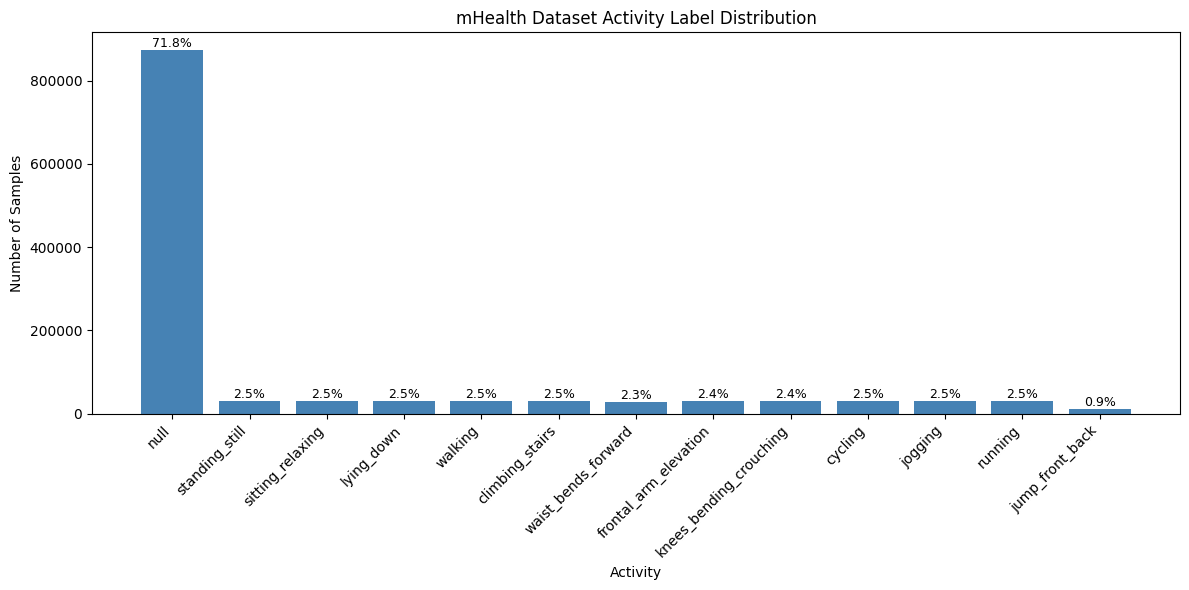

In [13]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Folder containing mHealth_subject*.log
base_dir = r"C:\Users\USER\Downloads\mhealth+dataset\MHEALTHDATASET"

activity_map = {
    0: "null",
    1: "standing_still",
    2: "sitting_relaxing",
    3: "lying_down",
    4: "walking",
    5: "climbing_stairs",
    6: "waist_bends_forward",
    7: "frontal_arm_elevation",
    8: "knees_bending_crouching",
    9: "cycling",
    10: "jogging",
    11: "running",
    12: "jump_front_back"
}

files = sorted(glob.glob(os.path.join(base_dir, "mHealth_subject*.log")))

all_counts = []

for file_path in files:
    df = pd.read_csv(file_path, sep=r"\s+", header=None)
    label_col = df.columns[-1]   # last column is label
    counts = df[label_col].value_counts().sort_index()

    for label, count in counts.items():
        all_counts.append({
            "label": int(label),
            "activity_name": activity_map.get(int(label), f"label_{label}"),
            "count": int(count)
        })

counts_df = pd.DataFrame(all_counts)

summary = (
    counts_df.groupby(["label", "activity_name"], as_index=False)["count"]
    .sum()
    .sort_values("label")
)

summary["percent"] = 100 * summary["count"] / summary["count"].sum()

print(summary)

plt.figure(figsize=(12, 6))
bars = plt.bar(summary["activity_name"], summary["count"], color="steelblue")

plt.title("mHealth Dataset Activity Label Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")

for bar, pct in zip(bars, summary["percent"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\USER\Downloads\mhealth+dataset\MHEALTHDATASET\mHealth_subject1.log"

columns = [
    "chest_acc_x", "chest_acc_y", "chest_acc_z",
    "ecg_1", "ecg_2",
    "ankle_acc_x", "ankle_acc_y", "ankle_acc_z",
    "ankle_gyro_x", "ankle_gyro_y", "ankle_gyro_z",
    "ankle_mag_x", "ankle_mag_y", "ankle_mag_z",
    "arm_acc_x", "arm_acc_y", "arm_acc_z",
    "arm_gyro_x", "arm_gyro_y", "arm_gyro_z",
    "arm_mag_x", "arm_mag_y", "arm_mag_z",
    "label"
]

activity_map = {
    0: "null",
    1: "standing_still",
    2: "sitting_relaxing",
    3: "lying_down",
    4: "walking",
    5: "climbing_stairs",
    6: "waist_bends_forward",
    7: "frontal_arm_elevation",
    8: "knees_bending_crouching",
    9: "cycling",
    10: "jogging",
    11: "running",
    12: "jump_front_back"
}

df = pd.read_csv(file_path, sep=r"\s+", header=None, names=columns)

sampling_rate = 50.0
df["sample_index"] = np.arange(len(df))
df["time_s"] = df["sample_index"] / sampling_rate
df["activity_name"] = df["label"].map(activity_map)

# ----------------------------
# IMU-derived features
# ----------------------------
df["chest_acc_mag"] = np.sqrt(df["chest_acc_x"]**2 + df["chest_acc_y"]**2 + df["chest_acc_z"]**2)
df["ankle_acc_mag"] = np.sqrt(df["ankle_acc_x"]**2 + df["ankle_acc_y"]**2 + df["ankle_acc_z"]**2)
df["arm_acc_mag"] = np.sqrt(df["arm_acc_x"]**2 + df["arm_acc_y"]**2 + df["arm_acc_z"]**2)

df["ankle_gyro_mag"] = np.sqrt(df["ankle_gyro_x"]**2 + df["ankle_gyro_y"]**2 + df["ankle_gyro_z"]**2)
df["arm_gyro_mag"] = np.sqrt(df["arm_gyro_x"]**2 + df["arm_gyro_y"]**2 + df["arm_gyro_z"]**2)

# ----------------------------
# ECG-derived features
# ----------------------------
window = int(sampling_rate)  # 1-second window

df["ecg_mean"] = (df["ecg_1"] + df["ecg_2"]) / 2.0
df["ecg_diff"] = df["ecg_1"] - df["ecg_2"]

df["ecg_1_mean_1s"] = df["ecg_1"].rolling(window=window, min_periods=1).mean()
df["ecg_1_std_1s"] = df["ecg_1"].rolling(window=window, min_periods=1).std()

df["ecg_2_mean_1s"] = df["ecg_2"].rolling(window=window, min_periods=1).mean()
df["ecg_2_std_1s"] = df["ecg_2"].rolling(window=window, min_periods=1).std()

df["ecg_mean_mean_1s"] = df["ecg_mean"].rolling(window=window, min_periods=1).mean()
df["ecg_mean_std_1s"] = df["ecg_mean"].rolling(window=window, min_periods=1).std()

df["ecg_diff_mean_1s"] = df["ecg_diff"].rolling(window=window, min_periods=1).mean()
df["ecg_diff_std_1s"] = df["ecg_diff"].rolling(window=window, min_periods=1).std()

df["ecg_1_range_1s"] = df["ecg_1"].rolling(window=window, min_periods=1).max() - df["ecg_1"].rolling(window=window, min_periods=1).min()
df["ecg_2_range_1s"] = df["ecg_2"].rolling(window=window, min_periods=1).max() - df["ecg_2"].rolling(window=window, min_periods=1).min()

df["ecg_energy_1s"] = (df["ecg_mean"]**2).rolling(window=window, min_periods=1).mean()

# ----------------------------
# Combined sensor summary
# ----------------------------
summary = df.groupby("activity_name").agg({
    "chest_acc_mag": ["mean", "std"],
    "ankle_acc_mag": ["mean", "std"],
    "arm_acc_mag": ["mean", "std"],
    "ankle_gyro_mag": ["mean", "std"],
    "arm_gyro_mag": ["mean", "std"],
    "ecg_1_mean_1s": ["mean", "std"],
    "ecg_2_mean_1s": ["mean", "std"],
    "ecg_1_range_1s": ["mean", "std"],
    "ecg_2_range_1s": ["mean", "std"],
    "ecg_energy_1s": ["mean", "std"]
})

print("First 5 rows:")
print(df.head())

print("\nPer-activity multimodal summary:")
print(summary)

output_file = r"C:\Users\USER\Downloads\mhealth+dataset\MHEALTHDATASET\mHealth_subject1_multimodal_features.csv"
df.to_csv(output_file, index=False)

print(f"\nSaved processed file to: {output_file}")

First 5 rows:
   chest_acc_x  chest_acc_y  chest_acc_z     ecg_1     ecg_2  ankle_acc_x  \
0      -9.8184     0.009971      0.29563  0.004186  0.004186       2.1849   
1      -9.8489     0.524040      0.37348  0.004186  0.016745       2.3876   
2      -9.6602     0.181850      0.43742  0.016745  0.037677       2.4086   
3      -9.6507     0.214220      0.24033  0.079540  0.117220       2.1814   
4      -9.7030     0.303890      0.31156  0.221870  0.205130       2.4173   

   ankle_acc_y  ankle_acc_z  ankle_gyro_x  ankle_gyro_y  ...  ecg_1_std_1s  \
0      -9.6967      0.63077      0.103900      -0.84053  ...           NaN   
1      -9.5080      0.68389      0.085343      -0.83865  ...      0.000000   
2      -9.5674      0.68113      0.085343      -0.83865  ...      0.007251   
3      -9.4301      0.55031      0.085343      -0.83865  ...      0.036073   
4      -9.3889      0.71098      0.085343      -0.83865  ...      0.092930   

   ecg_2_mean_1s  ecg_2_std_1s  ecg_mean_mean_1s  ecg_

In [15]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\USER\Downloads\mhealth+dataset\MHEALTHDATASET\mHealth_subject1.log"

columns = [
    "chest_acc_x", "chest_acc_y", "chest_acc_z",
    "ecg_1", "ecg_2",
    "ankle_acc_x", "ankle_acc_y", "ankle_acc_z",
    "ankle_gyro_x", "ankle_gyro_y", "ankle_gyro_z",
    "ankle_mag_x", "ankle_mag_y", "ankle_mag_z",
    "arm_acc_x", "arm_acc_y", "arm_acc_z",
    "arm_gyro_x", "arm_gyro_y", "arm_gyro_z",
    "arm_mag_x", "arm_mag_y", "arm_mag_z",
    "label"
]

activity_map = {
    0: "null",
    1: "standing_still",
    2: "sitting_relaxing",
    3: "lying_down",
    4: "walking",
    5: "climbing_stairs",
    6: "waist_bends_forward",
    7: "frontal_arm_elevation",
    8: "knees_bending_crouching",
    9: "cycling",
    10: "jogging",
    11: "running",
    12: "jump_front_back"
}

df = pd.read_csv(file_path, sep=r"\s+", header=None, names=columns)
fs = 50.0
df["time_s"] = np.arange(len(df)) / fs
df["activity_name"] = df["label"].map(activity_map)

# Combine the 2 ECG leads
df["ecg_mean"] = (df["ecg_1"] + df["ecg_2"]) / 2.0
df["ecg_diff"] = df["ecg_1"] - df["ecg_2"]

# Simple helper features
window = int(5 * fs)  # 5-second window
df["ecg_rms_5s"] = np.sqrt((df["ecg_mean"] ** 2).rolling(window, min_periods=1).mean())
df["ecg_std_5s"] = df["ecg_mean"].rolling(window, min_periods=1).std()
df["ecg_range_5s"] = df["ecg_mean"].rolling(window, min_periods=1).max() - df["ecg_mean"].rolling(window, min_periods=1).min()
df["ecg_energy_5s"] = (df["ecg_mean"] ** 2).rolling(window, min_periods=1).mean()

# Simple chest motion feature for fusion
df["chest_acc_mag"] = np.sqrt(df["chest_acc_x"]**2 + df["chest_acc_y"]**2 + df["chest_acc_z"]**2)
df["chest_acc_mean_5s"] = df["chest_acc_mag"].rolling(window, min_periods=1).mean()

# -------------------------------------------------------
# Peak-based HR / HRV proxy extraction on non-overlapping windows
# -------------------------------------------------------
def detect_peaks(signal, min_distance=15, threshold_factor=0.5):
    signal = np.asarray(signal)
    if len(signal) < 3:
        return np.array([], dtype=int)
    thr = signal.mean() + threshold_factor * signal.std()
    peaks = []
    last_peak = -min_distance
    for i in range(1, len(signal) - 1):
        if signal[i] > thr and signal[i] > signal[i - 1] and signal[i] > signal[i + 1]:
            if i - last_peak >= min_distance:
                peaks.append(i)
                last_peak = i
    return np.array(peaks, dtype=int)

rows = []
win_samples = int(5 * fs)

for start in range(0, len(df) - win_samples + 1, win_samples):
    end = start + win_samples
    seg = df.iloc[start:end].copy()
    ecg = seg["ecg_mean"].values
    peaks = detect_peaks(ecg, min_distance=int(0.4 * fs), threshold_factor=0.4)

    rr = np.diff(peaks) / fs if len(peaks) > 1 else np.array([])

    if len(rr) > 0:
        mean_rr = rr.mean()
        hr_bpm = 60.0 / mean_rr if mean_rr > 0 else np.nan
        sdnn = rr.std()
        rmssd = np.sqrt(np.mean(np.diff(rr) ** 2)) if len(rr) > 1 else np.nan
        pnn50 = np.mean(np.abs(np.diff(rr)) > 0.05) * 100 if len(rr) > 1 else np.nan
    else:
        hr_bpm = np.nan
        mean_rr = np.nan
        sdnn = np.nan
        rmssd = np.nan
        pnn50 = np.nan

    label_mode = seg["label"].mode().iloc[0]
    activity_name = activity_map.get(int(label_mode), "unknown")

    rows.append({
        "start_time_s": seg["time_s"].iloc[0],
        "end_time_s": seg["time_s"].iloc[-1],
        "label": int(label_mode),
        "activity_name": activity_name,
        "ecg_mean": seg["ecg_mean"].mean(),
        "ecg_std": seg["ecg_mean"].std(),
        "ecg_rms": np.sqrt(np.mean(ecg ** 2)),
        "ecg_range": np.max(ecg) - np.min(ecg),
        "ecg_energy": np.mean(ecg ** 2),
        "estimated_hr_bpm": hr_bpm,
        "mean_rr_s": mean_rr,
        "sdnn_s": sdnn,
        "rmssd_s": rmssd,
        "pnn50_pct": pnn50,
        "chest_acc_mean": seg["chest_acc_mag"].mean()
    })

features_df = pd.DataFrame(rows)

print(features_df.head())
print("\nAverage ECG/HRV-like features by activity:")
print(features_df.groupby("activity_name")[[
    "estimated_hr_bpm", "sdnn_s", "rmssd_s", "ecg_energy", "chest_acc_mean"
]].mean())

output_file = r"C:\Users\USER\Downloads\mhealth+dataset\MHEALTHDATASET\mHealth_subject1_ecg_features.csv"
features_df.to_csv(output_file, index=False)

print(f"\nSaved ECG feature file to: {output_file}")

   start_time_s  end_time_s  label activity_name  ecg_mean   ecg_std  \
0           0.0        4.98      0          null -0.049097  0.132326   
1           5.0        9.98      0          null -0.179257  0.150395   
2          10.0       14.98      0          null -0.077053  0.155334   
3          15.0       19.98      0          null -0.006941  0.153865   
4          20.0       24.98      0          null -0.005618  0.256622   

    ecg_rms  ecg_range  ecg_energy  estimated_hr_bpm  mean_rr_s    sdnn_s  \
0  0.140893   1.063320    0.019851         89.361702   0.671429  0.146914   
1  0.233797   1.184716    0.054661         94.170404   0.637143  0.218679   
2  0.173116   1.113550    0.029969        112.033195   0.535556  0.104468   
3  0.153714   1.287280    0.023628         90.909091   0.660000  0.190038   
4  0.256169   1.720565    0.065623         90.909091   0.660000  0.191833   

    rmssd_s   pnn50_pct  chest_acc_mean  
0  0.252323   83.333333        9.774470  
1  0.371842   83.333

In [3]:
import sys
!{sys.executable} -m pip install -U scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 43.1 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ------ --------------------------------- 6.3/37.3 MB 29.2 MB/s eta 0:00:02
   ------------- -------------------------- 12.3/37.3 MB 28.5 MB/s eta 0:00:01
   ------------------- -------------------- 17.8/37.3 MB 27.5 MB/s eta 0:00:01
   ----------------------- ---------------- 22.0/37.3 MB 25.4 MB/s eta 0:00:01
   ------------------------------ --------- 28.0/37.3 MB 25.9 MB/s eta 0:00:01
   ----------------------------------- ---- 32.8/37.3 MB 25.3 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.3 MB 24.5 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 23.0 MB/s  0:00:01

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\USER\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [4]:
import os
import glob
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --------------------------------------------------
# 1. Paths and constants
# --------------------------------------------------
base_dir = r"C:\Users\USER\Downloads\mhealth+dataset\MHEALTHDATASET"
files = sorted(glob.glob(os.path.join(base_dir, "mHealth_subject*.log")))

fs = 50  # Hz
window_sec = 5
window_size = fs * window_sec

columns = [
    "chest_acc_x", "chest_acc_y", "chest_acc_z",
    "ecg_1", "ecg_2",
    "ankle_acc_x", "ankle_acc_y", "ankle_acc_z",
    "ankle_gyro_x", "ankle_gyro_y", "ankle_gyro_z",
    "ankle_mag_x", "ankle_mag_y", "ankle_mag_z",
    "arm_acc_x", "arm_acc_y", "arm_acc_z",
    "arm_gyro_x", "arm_gyro_y", "arm_gyro_z",
    "arm_mag_x", "arm_mag_y", "arm_mag_z",
    "label"
]

activity_map = {
    0: "null",
    1: "standing_still",
    2: "sitting_relaxing",
    3: "lying_down",
    4: "walking",
    5: "climbing_stairs",
    6: "waist_bends_forward",
    7: "frontal_arm_elevation",
    8: "knees_bending_crouching",
    9: "cycling",
    10: "jogging",
    11: "running",
    12: "jump_front_back"
}

# --------------------------------------------------
# 2. Proxy fall / high-risk labels
# --------------------------------------------------
# You can change this mapping based on your research design.
high_risk_labels = {8, 10, 11, 12}  # crouching, jogging, running, jumping

def detect_peaks(signal, min_distance=15, threshold_factor=0.4):
    signal = np.asarray(signal)
    if len(signal) < 3:
        return np.array([], dtype=int)
    thr = signal.mean() + threshold_factor * signal.std()
    peaks = []
    last_peak = -min_distance
    for i in range(1, len(signal) - 1):
        if signal[i] > thr and signal[i] > signal[i - 1] and signal[i] > signal[i + 1]:
            if i - last_peak >= min_distance:
                peaks.append(i)
                last_peak = i
    return np.array(peaks, dtype=int)

def extract_window_features(seg):
    # Accelerometer magnitudes
    chest_acc_mag = np.sqrt(seg["chest_acc_x"]**2 + seg["chest_acc_y"]**2 + seg["chest_acc_z"]**2)
    ankle_acc_mag = np.sqrt(seg["ankle_acc_x"]**2 + seg["ankle_acc_y"]**2 + seg["ankle_acc_z"]**2)
    arm_acc_mag = np.sqrt(seg["arm_acc_x"]**2 + seg["arm_acc_y"]**2 + seg["arm_acc_z"]**2)

    # ECG combined signal
    ecg = (seg["ecg_1"].values + seg["ecg_2"].values) / 2.0

    # Basic ECG features
    ecg_mean = np.mean(ecg)
    ecg_std = np.std(ecg)
    ecg_rms = np.sqrt(np.mean(ecg**2))
    ecg_range = np.max(ecg) - np.min(ecg)
    ecg_energy = np.mean(ecg**2)

    # Peak-based HRV-like features
    peaks = detect_peaks(ecg, min_distance=int(0.4 * fs), threshold_factor=0.4)
    rr = np.diff(peaks) / fs if len(peaks) > 1 else np.array([])

    if len(rr) > 0:
        mean_rr = rr.mean()
        hr_bpm = 60.0 / mean_rr if mean_rr > 0 else np.nan
        sdnn = rr.std()
        rmssd = np.sqrt(np.mean(np.diff(rr)**2)) if len(rr) > 1 else 0.0
    else:
        hr_bpm = np.nan
        mean_rr = np.nan
        sdnn = np.nan
        rmssd = np.nan

    feats = {
        # Chest accelerometer
        "chest_acc_mean": chest_acc_mag.mean(),
        "chest_acc_std": chest_acc_mag.std(),
        "chest_acc_max": chest_acc_mag.max(),

        # Ankle accelerometer
        "ankle_acc_mean": ankle_acc_mag.mean(),
        "ankle_acc_std": ankle_acc_mag.std(),
        "ankle_acc_max": ankle_acc_mag.max(),

        # Arm accelerometer
        "arm_acc_mean": arm_acc_mag.mean(),
        "arm_acc_std": arm_acc_mag.std(),
        "arm_acc_max": arm_acc_mag.max(),

        # ECG
        "ecg_mean": ecg_mean,
        "ecg_std": ecg_std,
        "ecg_rms": ecg_rms,
        "ecg_range": ecg_range,
        "ecg_energy": ecg_energy,
        "hr_bpm": hr_bpm,
        "mean_rr": mean_rr,
        "sdnn": sdnn,
        "rmssd": rmssd
    }
    return feats

# --------------------------------------------------
# 3. Build windowed dataset
# --------------------------------------------------
rows = []

for file_path in files:
    df = pd.read_csv(file_path, sep=r"\s+", header=None, names=columns)
    subject = os.path.basename(file_path).replace("mHealth_subject", "").replace(".log", "")

    for start in range(0, len(df) - window_size + 1, window_size):
        end = start + window_size
        seg = df.iloc[start:end].copy()

        label_mode = int(seg["label"].mode().iloc[0])
        activity_name = activity_map.get(label_mode, "unknown")
        binary_target = 1 if label_mode in high_risk_labels else 0

        feats = extract_window_features(seg)
        feats["subject"] = subject
        feats["label"] = label_mode
        feats["activity_name"] = activity_name
        feats["fall_risk_proxy"] = binary_target

        rows.append(feats)

dataset = pd.DataFrame(rows)

# Drop rows with missing ECG-derived HR features
dataset = dataset.dropna().reset_index(drop=True)

print("Windowed dataset shape:", dataset.shape)
print(dataset.head())

# --------------------------------------------------
# 4. Train/test split
# --------------------------------------------------
feature_cols = [
    "chest_acc_mean", "chest_acc_std", "chest_acc_max",
    "ankle_acc_mean", "ankle_acc_std", "ankle_acc_max",
    "arm_acc_mean", "arm_acc_std", "arm_acc_max",
    "ecg_mean", "ecg_std", "ecg_rms", "ecg_range", "ecg_energy",
    "hr_bpm", "mean_rr", "sdnn", "rmssd"
]

X = dataset[feature_cols]
y = dataset["fall_risk_proxy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --------------------------------------------------
# 5. Train model
# --------------------------------------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# --------------------------------------------------
# 6. Evaluate
# --------------------------------------------------
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

# --------------------------------------------------
# 7. Feature importance
# --------------------------------------------------
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop feature importances:")
print(importance_df.head(10))

# --------------------------------------------------
# 8. Save outputs
# --------------------------------------------------
dataset.to_csv(os.path.join(base_dir, "mhealth_ecg_acc_windowed_features.csv"), index=False)
importance_df.to_csv(os.path.join(base_dir, "mhealth_ecg_acc_feature_importance.csv"), index=False)

print("\nSaved:")
print(os.path.join(base_dir, "mhealth_ecg_acc_windowed_features.csv"))
print(os.path.join(base_dir, "mhealth_ecg_acc_feature_importance.csv"))

Windowed dataset shape: (4859, 22)
   chest_acc_mean  chest_acc_std  chest_acc_max  ankle_acc_mean  \
0        9.774470       0.124548      10.103934        9.812959   
1        9.787774       0.134540      10.102980        9.778972   
2        9.800388       0.175209      10.533480        9.849057   
3        9.789186       0.143857      10.165595        9.828502   
4        9.851834       1.329289      14.646581       11.710650   

   ankle_acc_std  ankle_acc_max  arm_acc_mean  arm_acc_std  arm_acc_max  \
0       0.105241      10.081675      9.754509     0.135489    10.133044   
1       0.109223      10.065099      9.760038     0.107669    10.189701   
2       0.390925      13.389496      9.832732     0.553794    12.083363   
3       0.154961      10.860348      9.755450     0.145818    10.341218   
4       4.269665      33.727275      9.774153     1.584652    15.945028   

   ecg_mean  ...  ecg_range  ecg_energy      hr_bpm   mean_rr      sdnn  \
0 -0.049097  ...   1.063320    0.019